In [2]:
print("=" * 70)
print(" MOVIE RATING PREDICTION PROJECT ".center(70))
print("=" * 70)

print("\n[1] Importing Libraries...\n")

import pandas as pd
import matplotlib.pyplot as plt
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries Imported Successfully!")


                   MOVIE RATING PREDICTION PROJECT                    

[1] Importing Libraries...

Libraries Imported Successfully!


In [3]:
print("\n" + "=" * 70)
print("IMDb Movies India.csv.zip".center(70))
print("=" * 70)

with zipfile.ZipFile("IMDb Movies India.csv.zip", 'r') as zip_ref:
    zip_ref.extractall("movie_data")

print("\nZIP File Extracted Successfully!")



                      IMDb Movies India.csv.zip                       

ZIP File Extracted Successfully!


In [4]:
print("\n" + "=" * 70)
print("[3] LOADING DATASET".center(70))
print("=" * 70)

# Load dataset
data = pd.read_csv("movie_data/IMDb Movies India.csv", encoding='latin1')

print("\nDataset Loaded Successfully!")

print("\n" + "=" * 70)
print("[4] FIRST 5 ROWS OF DATASET".center(70))
print("=" * 70)

print(data.head())


                         [3] LOADING DATASET                          

Dataset Loaded Successfully!

                     [4] FIRST 5 ROWS OF DATASET                      
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN 

In [5]:
print("\n" + "=" * 70)
print("[5] CLEANING DATASET".center(70))
print("=" * 70)

# Select important columns
data = data[[
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3",
    "Rating"
]]

# Remove missing values
data = data.dropna()

print("\nMissing Values Removed Successfully!")



                         [5] CLEANING DATASET                         

Missing Values Removed Successfully!


In [6]:
print("\n" + "=" * 70)
print("[6] ENCODING DATA".center(70))
print("=" * 70)

encoder = LabelEncoder()

data["Genre"] = encoder.fit_transform(data["Genre"])
data["Director"] = encoder.fit_transform(data["Director"])
data["Actor 1"] = encoder.fit_transform(data["Actor 1"])
data["Actor 2"] = encoder.fit_transform(data["Actor 2"])
data["Actor 3"] = encoder.fit_transform(data["Actor 3"])

print("\nCategorical Data Converted Successfully!")


                          [6] ENCODING DATA                           

Categorical Data Converted Successfully!


In [7]:
print("\n" + "=" * 70)
print("[7] SELECTING FEATURES".center(70))
print("=" * 70)

X = data[[
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]]

y = data["Rating"]

print("\nFeatures Selected Successfully!")



                        [7] SELECTING FEATURES                        

Features Selected Successfully!


In [8]:
print("\n" + "=" * 70)
print("[8] SPLITTING DATASET".center(70))
print("=" * 70)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("\nDataset Split Successfully!")


                        [8] SPLITTING DATASET                         

Dataset Split Successfully!


In [9]:
print("\n" + "=" * 70)
print("[9] TRAINING MODEL".center(70))
print("=" * 70)
model = RandomForestRegressor()
model.fit(X_train, y_train)
print("\nModel Training Completed Successfully!")



                          [9] TRAINING MODEL                          

Model Training Completed Successfully!


In [10]:
print("\n" + "=" * 70)
print("[10] PREDICTING MOVIE RATINGS".center(70))
print("=" * 70)

prediction = model.predict(X_test)

print("\nPrediction Completed Successfully!")

print("\n" + "=" * 70)
print("MODEL PERFORMANCE".center(70))
print("=" * 70)

mae = mean_absolute_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

print(f"\nMean Absolute Error : {mae:.2f}")
print(f"R2 Score             : {r2:.2f}")


                    [10] PREDICTING MOVIE RATINGS                     

Prediction Completed Successfully!

                          MODEL PERFORMANCE                           

Mean Absolute Error : 1.03
R2 Score             : 0.08


In [11]:
print("\n" + "=" * 70)
print("CUSTOM MOVIE RATING PREDICTION".center(70))
print("=" * 70)

# Example Movie Data
sample_movie = X.iloc[[0]]

predicted_rating = model.predict(sample_movie)

print("\nPredicted Movie Rating :", round(predicted_rating[0], 2))



                    CUSTOM MOVIE RATING PREDICTION                    

Predicted Movie Rating : 6.11



Displaying Rating Distribution Graph...



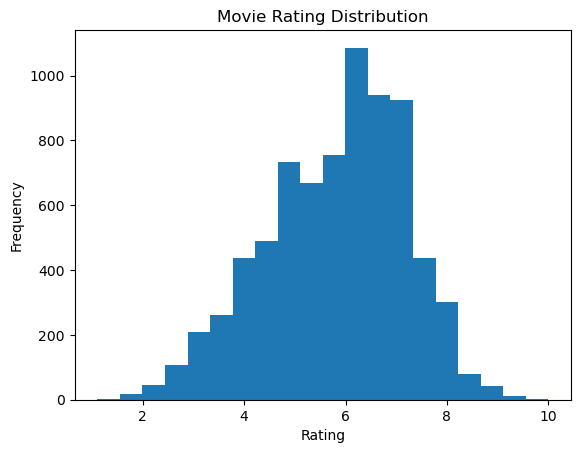

In [12]:
print("\nDisplaying Rating Distribution Graph...\n")
data["Rating"].plot(kind="hist", bins=20)
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


Displaying Genre Graph...



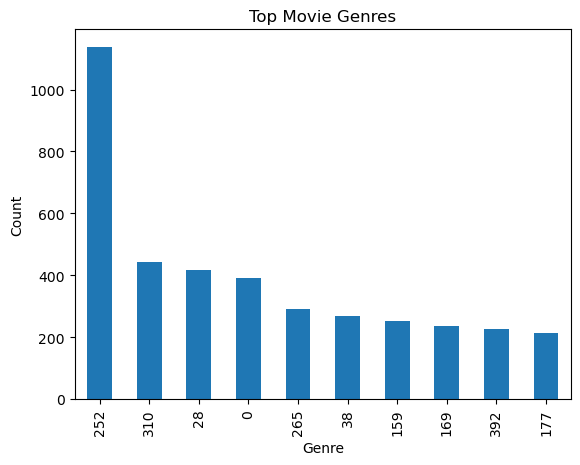

In [13]:
print("\nDisplaying Genre Graph...\n")
data["Genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


Displaying Director Graph...



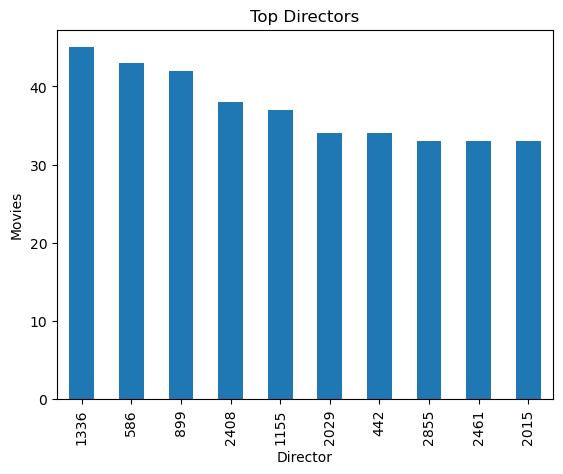

In [14]:
print("\nDisplaying Director Graph...\n")
data["Director"].value_counts().head(10).plot(kind="bar")
plt.title("Top Directors")
plt.xlabel("Director")
plt.ylabel("Movies")
plt.show()


Displaying Actor Graph...



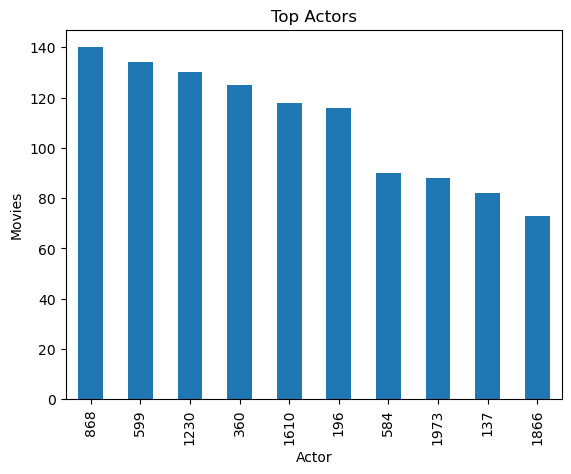

In [15]:
print("\nDisplaying Actor Graph...\n")
data["Actor 1"].value_counts().head(10).plot(kind="bar")
plt.title("Top Actors")
plt.xlabel("Actor")
plt.ylabel("Movies")
plt.show()


Displaying Actual vs Predicted Ratings Graph...



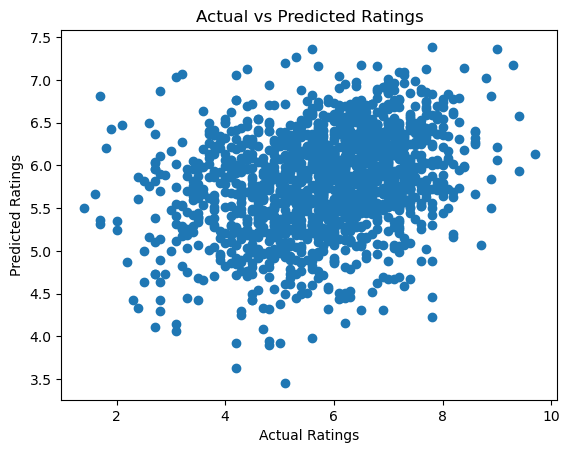


                    PROJECT COMPLETED SUCCESSFULLY                    


In [16]:
print("\nDisplaying Actual vs Predicted Ratings Graph...\n")
plt.scatter(y_test, prediction)
plt.title("Actual vs Predicted Ratings")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.show()
print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY".center(70))
print("=" * 70)